# Procesamiento de Lenguaje Natural: Frankenstein
## Flujo Completo: Carga → Limpieza → Vectorización → Embeddings

**Checkpoint 4 - Semántica Distribucional**

Proyecto final que demuestra el pipeline completo de PLN aplicado al clásico "Frankenstein" de Mary Shelley.

## Parte 0: Importar Librerías

In [1]:
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import Word2Vec
import multiprocessing
import warnings

warnings.filterwarnings('ignore')

print("✓ Todas las librerías importadas correctamente")
print(f"  - spaCy: {spacy.__version__}")
print(f"  - Procesadores disponibles: {multiprocessing.cpu_count()}")

✓ Todas las librerías importadas correctamente
  - spaCy: 3.7.2
  - Procesadores disponibles: 12


# ETAPA 1: CARGA DE DATOS

## 1.1 Cargar modelo de spaCy

In [2]:
print("[1.1] Cargando modelo de spaCy...")
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    print("Descargando modelo...")
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

print("✓ Modelo cargado: en_core_web_sm")

[1.1] Cargando modelo de spaCy...
✓ Modelo cargado: en_core_web_sm


## 1.2 Cargar archivo de texto

In [3]:
print("\n[1.2] Cargando Frankenstein...")
with open("libro.txt", "r", encoding="utf-8") as f:
    texto_frankenstein = f.read()

print(f"✓ Archivo cargado exitosamente")
print(f"  - Longitud: {len(texto_frankenstein):,} caracteres")
print(f"  - Primeros 200 caracteres:")
print(f"    {texto_frankenstein[:200]}...")


[1.2] Cargando Frankenstein...
✓ Archivo cargado exitosamente
  - Longitud: 438,842 caracteres
  - Primeros 200 caracteres:
    ﻿The Project Gutenberg eBook of Frankenstein; or, the modern prometheus
    
This eBook is for the use of anyone anywhere in the United States and
most other parts of the world at no cost and with alm...


# ETAPA 2: PROCESAMIENTO Y LIMPIEZA

## 2.1 Tokenización

In [4]:
print("\n[2.1] Tokenización con spaCy...")
doc = nlp(texto_frankenstein)

print(f"✓ Tokenización completada")
print(f"  - Total de tokens: {len(doc):,}")
print(f"  - Primeros 30 tokens: {[token.text for token in doc][:30]}")


[2.1] Tokenización con spaCy...
✓ Tokenización completada
  - Total de tokens: 96,083
  - Primeros 30 tokens: ['\ufeffThe', 'Project', 'Gutenberg', 'eBook', 'of', 'Frankenstein', ';', 'or', ',', 'the', 'modern', 'prometheus', '\n    \n', 'This', 'eBook', 'is', 'for', 'the', 'use', 'of', 'anyone', 'anywhere', 'in', 'the', 'United', 'States', 'and', '\n', 'most', 'other']


## 2.2 Procesamiento por Oraciones (Lematización)

In [5]:
print("\n[2.2] Lematizando por oraciones...")

corpus_lematizado = []
sentences_word2vec = []  # Para Word2Vec usamos lista de listas

for oracion in doc.sents:
    # Lematizar cada token
    lemas_oracion = [
        token.lemma_.lower()
        for token in oracion
        if not token.is_punct and not token.is_space and not token.is_stop
    ]
    
    # Agregar si tiene contenido
    if len(lemas_oracion) > 1:
        corpus_lematizado.append(" ".join(lemas_oracion))
        sentences_word2vec.append(lemas_oracion)

print(f"✓ Procesamiento completado")
print(f"  - Total de oraciones: {len(corpus_lematizado):,}")
print(f"  - Primeras 3 oraciones:")
for i, oracion in enumerate(corpus_lematizado[:3]):
    print(f"    {i+1}. {oracion[:100]}...")


[2.2] Lematizando por oraciones...
✓ Procesamiento completado
  - Total de oraciones: 3,249
  - Primeras 3 oraciones:
    1. ﻿the project gutenberg ebook frankenstein modern prometheus ebook use united states part world cost ...
    2. copy away use term project gutenberg license include ebook online www.gutenberg.org...
    3. locate united states check law country locate ebook...


# ETAPA 3: VECTORIZACIÓN CLÁSICA (BoW + TF-IDF)

## 3.1 Bag-of-Words

In [6]:
print("\n[3.1] Vectorización Bag-of-Words...")

bow_vectorizer = CountVectorizer(max_features=100)
X_bow = bow_vectorizer.fit_transform(corpus_lematizado)
vocab_bow = bow_vectorizer.get_feature_names_out()

print(f"✓ BoW completado")
print(f"  - Forma: {X_bow.shape}")
print(f"  - Top 10 palabras: {list(vocab_bow[:10])}")

# Estadísticas
bow_sums = np.array(X_bow.sum(axis=0)).ravel()
top_indices = np.argsort(bow_sums)[-5:][::-1]
print(f"\n  Top 5 palabras por frecuencia:")
for idx in top_indices:
    print(f"    - {vocab_bow[idx]:20} → {bow_sums[idx]:.0f} apariciones")


[3.1] Vectorización Bag-of-Words...
✓ BoW completado
  - Forma: (3249, 100)
  - Top 10 palabras: ['affection', 'appear', 'away', 'believe', 'cause', 'chapter', 'child', 'clerval', 'come', 'cottage']

  Top 5 palabras por frecuencia:
    - man                  → 180 apariciones
    - father               → 134 apariciones
    - day                  → 133 apariciones
    - feel                 → 132 apariciones
    - work                 → 126 apariciones


## 3.2 TF-IDF

In [7]:
print("\n[3.2] Vectorización TF-IDF...")

tfidf_vectorizer = TfidfVectorizer(max_features=100)
X_tfidf = tfidf_vectorizer.fit_transform(corpus_lematizado)
vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print(f"✓ TF-IDF completado")
print(f"  - Forma: {X_tfidf.shape}")
print(f"  - Top 10 palabras: {list(vocab_tfidf[:10])}")

# Estadísticas
tfidf_sums = np.array(X_tfidf.sum(axis=0)).ravel()
top_indices = np.argsort(tfidf_sums)[-5:][::-1]
print(f"\n  Top 5 palabras por importancia (TF-IDF):")
for idx in top_indices:
    print(f"    - {vocab_tfidf[idx]:20} → {tfidf_sums[idx]:.4f} importancia")


[3.2] Vectorización TF-IDF...
✓ TF-IDF completado
  - Forma: (3249, 100)
  - Top 10 palabras: ['affection', 'appear', 'away', 'believe', 'cause', 'chapter', 'child', 'clerval', 'come', 'cottage']

  Top 5 palabras por importancia (TF-IDF):
    - man                  → 93.8919 importancia
    - feel                 → 72.7098 importancia
    - day                  → 71.0086 importancia
    - father               → 69.7183 importancia
    - life                 → 68.7597 importancia


# ETAPA 4: VECTORIZACIÓN CON SEMÁNTICA DISTRIBUCIONAL (Word2Vec)

## 4.1 Entrenamiento de Word2Vec

In [8]:
print("\n[4.1] Entrenando Word2Vec (Skip-gram)...")

# Parámetros explicados:
# - vector_size: Dimensión de los embeddings (50 = vector de 50 números)
# - window: Contexto (cuántas palabras antes y después se consideran)
# - min_count: Incluir palabras que aparecen al menos X veces
# - sg=1: Skip-gram (1) vs CBOW (0)
# - workers: Usar múltiples CPUs para acelerar

w2v_model = Word2Vec(
    sentences_word2vec,
    vector_size=50,      # 50 dimensiones (embeddings densos)
    window=5,            # Contexto de 5 palabras
    min_count=2,         # Mínimo 2 apariciones
    sg=1,                # Skip-gram
    workers=multiprocessing.cpu_count(),
    epochs=10,           # Entrenar 10 épocas
    seed=42
)

print(f"✓ Word2Vec entrenado")
print(f"  - Vocabulario: {len(w2v_model.wv)} palabras")
print(f"  - Dimensión de embeddings: {w2v_model.vector_size}")
print(f"  - Épocas: 10")
print(f"  - Tamaño de contexto: 5 palabras")


[4.1] Entrenando Word2Vec (Skip-gram)...
✓ Word2Vec entrenado
  - Vocabulario: 3188 palabras
  - Dimensión de embeddings: 50
  - Épocas: 10
  - Tamaño de contexto: 5 palabras


## 4.2 Exploración de Similitudes Semánticas

In [9]:
print("\n[4.2] Explorando similitudes semánticas...\n")

def mostrar_similares(palabra, topn=5):
    try:
        similares = w2v_model.wv.most_similar(palabra, topn=topn)
        print(f"Palabras más cercanas a '{palabra}':")
        for word, sim in similares:
            print(f"  • {word:20} (Similitud: {sim:.4f})")
    except KeyError:
        print(f"La palabra '{palabra}' no está en el vocabulario.")
    print()

# Palabras clave de Frankenstein
palabras_clave = ['creature', 'monster', 'victor', 'life', 'death', 'love']

for palabra in palabras_clave:
    if palabra in w2v_model.wv:
        mostrar_similares(palabra, topn=4)
    else:
        print(f"'{palabra}' no está en el vocabulario.\n")


[4.2] Explorando similitudes semánticas...

Palabras más cercanas a 'creature':
  • wish                 (Similitud: 0.9688)
  • being                (Similitud: 0.9653)
  • bestow               (Similitud: 0.9641)
  • kindness             (Similitud: 0.9631)

Palabras más cercanas a 'monster':
  • wretch               (Similitud: 0.9948)
  • agitation            (Similitud: 0.9942)
  • bitter               (Similitud: 0.9933)
  • fiend                (Similitud: 0.9925)

Palabras más cercanas a 'victor':
  • cousin               (Similitud: 0.9893)
  • friend               (Similitud: 0.9856)
  • clerval              (Similitud: 0.9850)
  • say                  (Similitud: 0.9846)

Palabras más cercanas a 'life':
  • restore              (Similitud: 0.9830)
  • grief                (Similitud: 0.9822)
  • moment               (Similitud: 0.9822)
  • happiness            (Similitud: 0.9822)

Palabras más cercanas a 'death':
  • murder               (Similitud: 0.9767)
  • peace       

## 4.3 Visualización 3D: Embeddings Word2Vec con PCA


[4.3] Generando visualización 3D de embeddings...

✓ Gráfico guardado: frankenstein_word2vec_3d.png


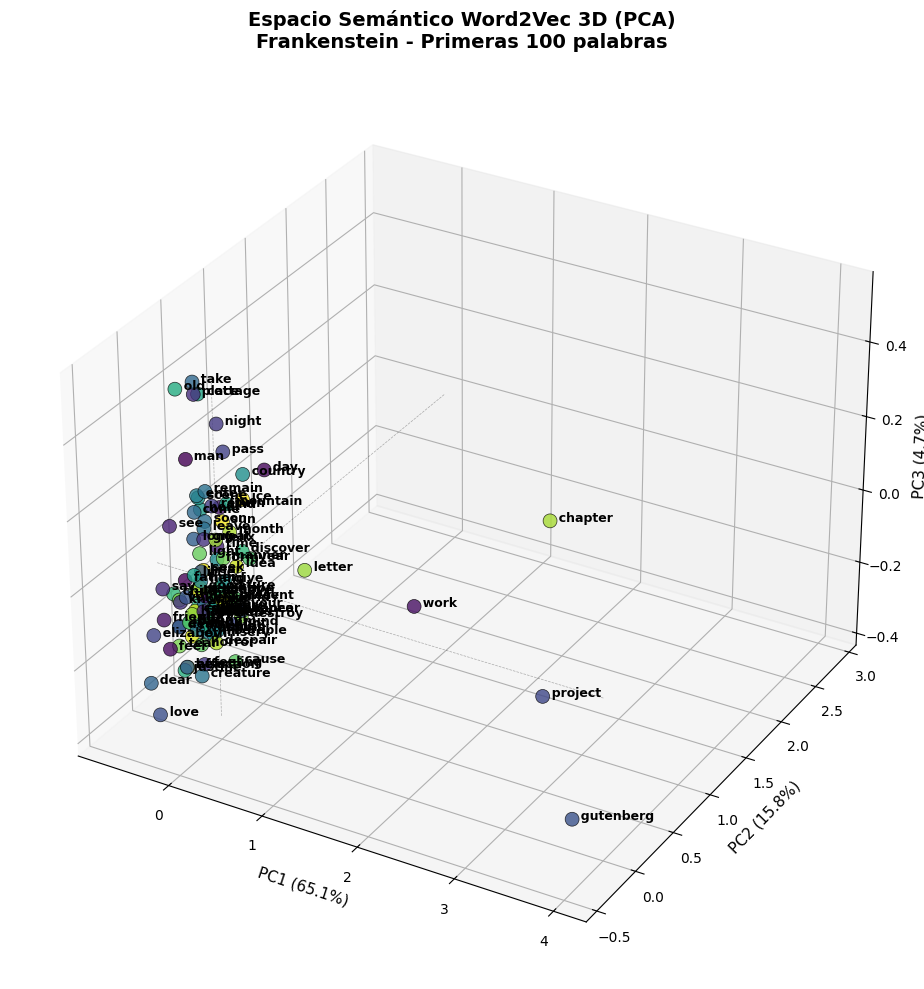


Varianza Explicada (PCA):
  PC1: 65.10%
  PC2: 15.85%
  PC3: 4.74%
  Total: 85.69%


In [10]:
print("\n[4.3] Generando visualización 3D de embeddings...\n")

# Obtener vectores y palabras
vocabulario_w2v = list(w2v_model.wv.index_to_key)[:100]  # Limitamos a 100 palabras
vectores_w2v = w2v_model.wv[vocabulario_w2v]

# Reducción de dimensionalidad con PCA
pca_w2v = PCA(n_components=3, random_state=42)
vectores_3d = pca_w2v.fit_transform(vectores_w2v)

# Crear figura
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
scatter = ax.scatter(vectores_3d[:, 0], vectores_3d[:, 1], vectores_3d[:, 2],
                     c=range(len(vectores_3d)), cmap='viridis',
                     s=100, edgecolors='black', alpha=0.8, linewidth=0.5)

# Etiquetas
for i, palabra in enumerate(vocabulario_w2v):
    ax.text(vectores_3d[i, 0], vectores_3d[i, 1], vectores_3d[i, 2],
           f'  {palabra}', fontsize=9, weight='bold')

# Configurar ejes
ax.set_title(f'Espacio Semántico Word2Vec 3D (PCA)\nFrankenstein - Primeras 100 palabras',
             fontsize=14, weight='bold', pad=20)
ax.set_xlabel(f'PC1 ({pca_w2v.explained_variance_ratio_[0]:.1%})', fontsize=11)
ax.set_ylabel(f'PC2 ({pca_w2v.explained_variance_ratio_[1]:.1%})', fontsize=11)
ax.set_zlabel(f'PC3 ({pca_w2v.explained_variance_ratio_[2]:.1%})', fontsize=11)

# Líneas de referencia
ax.plot([0, 0], [0, 0], [vectores_3d[:, 2].min(), vectores_3d[:, 2].max()],
       'k--', alpha=0.3, linewidth=0.5)
ax.plot([vectores_3d[:, 0].min(), vectores_3d[:, 0].max()], [0, 0], [0, 0],
       'k--', alpha=0.3, linewidth=0.5)
ax.plot([0, 0], [vectores_3d[:, 1].min(), vectores_3d[:, 1].max()], [0, 0],
       'k--', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.savefig('frankenstein_word2vec_3d.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado: frankenstein_word2vec_3d.png")
plt.show()

# Mostrar varianza explicada
print(f"\nVarianza Explicada (PCA):")
for i, var in enumerate(pca_w2v.explained_variance_ratio_):
    print(f"  PC{i+1}: {var:.2%}")
print(f"  Total: {pca_w2v.explained_variance_ratio_.sum():.2%}")

## 4.4 Heatmap de Embeddings (Matriz de Palabras)


[4.4] Generando heatmap de embeddings...

✓ Gráfico guardado: frankenstein_embeddings_heatmap.png


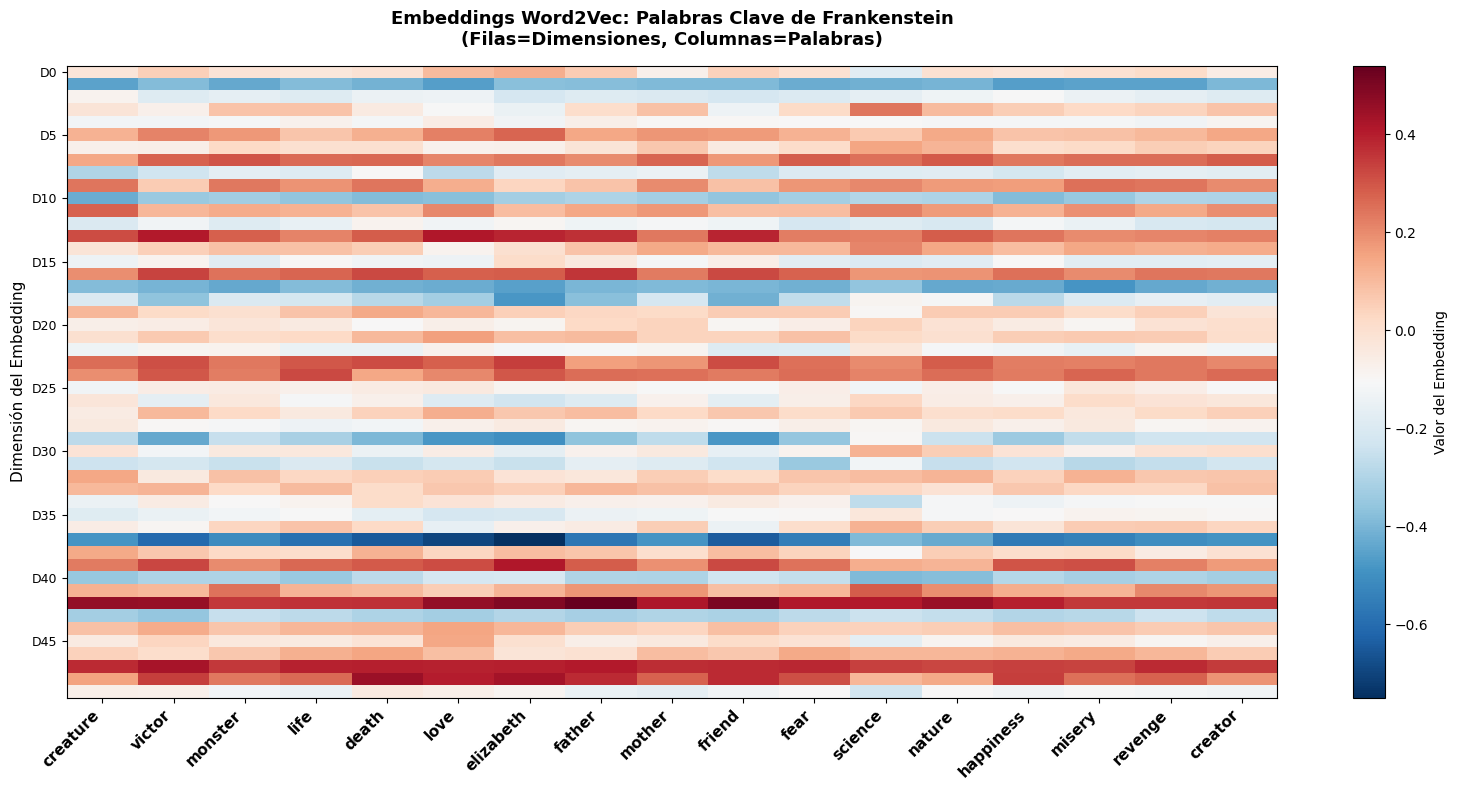


Palabras analizadas: 17/18
Dimensión de cada embedding: 50


In [11]:
print("\n[4.4] Generando heatmap de embeddings...\n")

# Seleccionar palabras importantes
palabras_top = ['creature', 'victor', 'monster', 'life', 'death', 'love',
                'elizabeth', 'father', 'mother', 'friend', 'fear', 'science',
                'nature', 'alchemy', 'happiness', 'misery', 'revenge', 'creator']

# Filtrar palabras que están en el modelo
palabras_existentes = [p for p in palabras_top if p in w2v_model.wv]

# Obtener embeddings
embeddings_top = w2v_model.wv[palabras_existentes]

# Crear heatmap
fig, ax = plt.subplots(figsize=(16, 8))

im = ax.imshow(embeddings_top.T, cmap='RdBu_r', aspect='auto')
ax.set_yticks(range(0, embeddings_top.shape[1], 5))
ax.set_yticklabels([f'D{i}' for i in range(0, embeddings_top.shape[1], 5)], fontsize=9)
ax.set_xticks(range(len(palabras_existentes)))
ax.set_xticklabels(palabras_existentes, rotation=45, ha='right', fontsize=11, weight='bold')

ax.set_title('Embeddings Word2Vec: Palabras Clave de Frankenstein\n(Filas=Dimensiones, Columnas=Palabras)',
             fontsize=13, weight='bold', pad=15)
ax.set_ylabel('Dimensión del Embedding', fontsize=11)

# Colorbar
cbar = plt.colorbar(im, ax=ax, label='Valor del Embedding')

plt.tight_layout()
plt.savefig('frankenstein_embeddings_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado: frankenstein_embeddings_heatmap.png")
plt.show()

print(f"\nPalabras analizadas: {len(palabras_existentes)}/{len(palabras_top)}")
print(f"Dimensión de cada embedding: {embeddings_top.shape[1]}")

## 4.5 Matriz de Similitud (Coseno)


[4.5] Calculando matriz de similitud coseno...

✓ Gráfico guardado: frankenstein_similitud_semantica.png


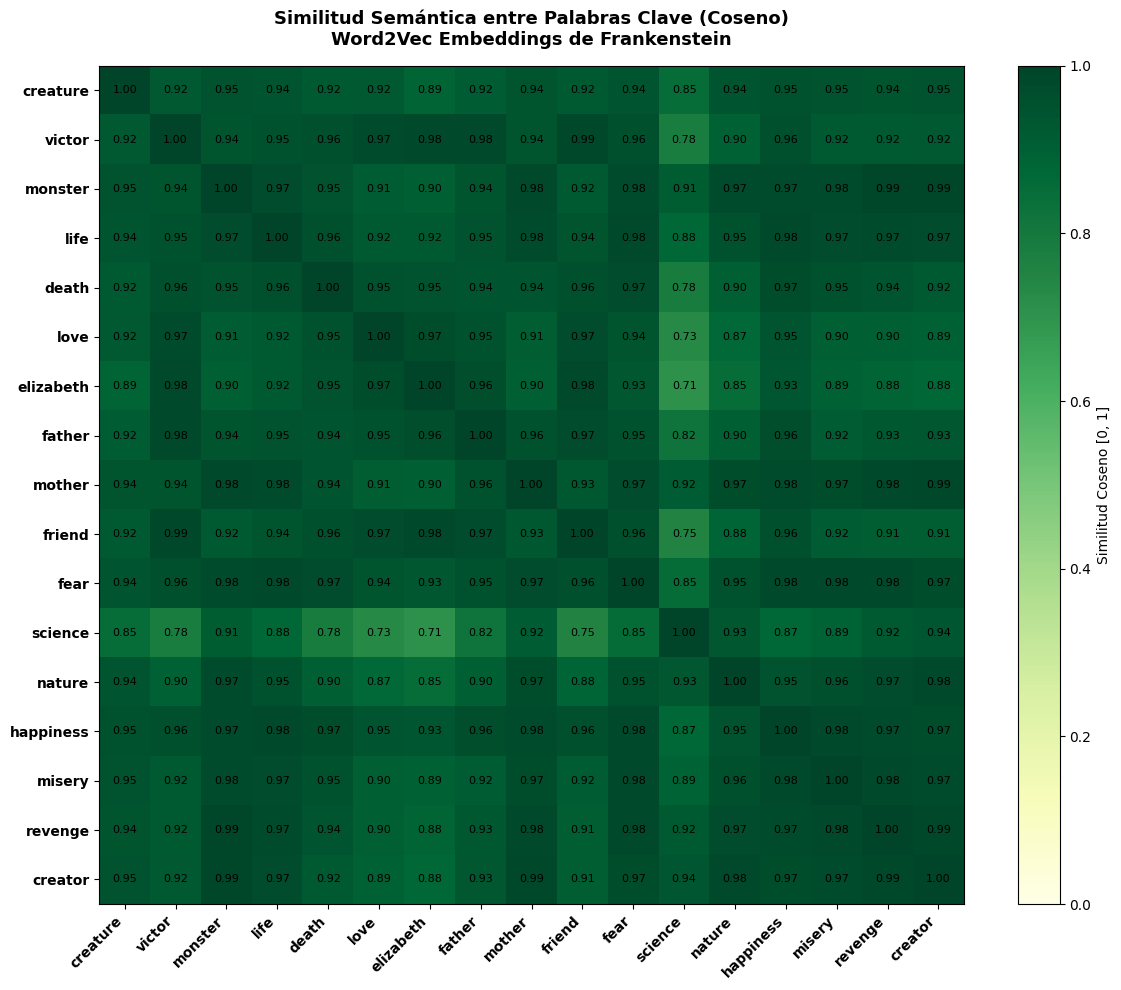


Pares de palabras más similares semánticamente:
  • 'monster' ↔ 'revenge': 0.9894
  • 'monster' ↔ 'creator': 0.9888
  • 'mother' ↔ 'creator': 0.9858
  • 'revenge' ↔ 'creator': 0.9856
  • 'victor' ↔ 'friend': 0.9856
  • 'fear' ↔ 'happiness': 0.9834
  • 'monster' ↔ 'mother': 0.9827
  • 'misery' ↔ 'revenge': 0.9825
  • 'life' ↔ 'happiness': 0.9822
  • 'victor' ↔ 'elizabeth': 0.9815


In [12]:
print("\n[4.5] Calculando matriz de similitud coseno...\n")

# Usar las mismas palabras importantes
similitud_matrix = cosine_similarity(embeddings_top)

# Crear heatmap
fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(similitud_matrix, cmap='YlGn', aspect='auto', vmin=0, vmax=1)

# Etiquetas
ax.set_xticks(range(len(palabras_existentes)))
ax.set_yticks(range(len(palabras_existentes)))
ax.set_xticklabels(palabras_existentes, rotation=45, ha='right', fontsize=10, weight='bold')
ax.set_yticklabels(palabras_existentes, fontsize=10, weight='bold')

ax.set_title('Similitud Semántica entre Palabras Clave (Coseno)\nWord2Vec Embeddings de Frankenstein',
             fontsize=13, weight='bold', pad=15)

# Colorbar
cbar = plt.colorbar(im, ax=ax, label='Similitud Coseno [0, 1]')

# Agregar valores a las celdas
for i in range(len(palabras_existentes)):
    for j in range(len(palabras_existentes)):
        text = ax.text(j, i, f'{similitud_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

plt.tight_layout()
plt.savefig('frankenstein_similitud_semantica.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado: frankenstein_similitud_semantica.png")
plt.show()

# Mostrar pares más similares
print("\nPares de palabras más similares semánticamente:")
pares_similares = []
for i in range(len(palabras_existentes)):
    for j in range(i+1, len(palabras_existentes)):
        sim = similitud_matrix[i, j]
        pares_similares.append((palabras_existentes[i], palabras_existentes[j], sim))

pares_similares.sort(key=lambda x: x[2], reverse=True)
for w1, w2, sim in pares_similares[:10]:
    print(f"  • '{w1}' ↔ '{w2}': {sim:.4f}")

# ETAPA 5: COMPARACIÓN GLOBAL

## 5.1 Tabla Comparativa de Métodos

In [13]:
print("\n[5.1] Comparación de métodos de vectorización\n")

comparacion = pd.DataFrame({
    'Método': ['Bag-of-Words', 'TF-IDF', 'Word2Vec'],
    'Tipo': ['Conteos', 'Ponderación', 'Embedding'],
    'Dimensión': [X_bow.shape[1], X_tfidf.shape[1], w2v_model.vector_size],
    'Densidad': [
        f"{X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]) * 100:.1f}%",
        f"{X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.1f}%",
        "100% (Denso)"
    ],
    'Contexto': ['No', 'No', 'Sí (ventana)'],
    'Interpretabilidad': ['Alta', 'Alta', 'Baja'],
    'Uso Típico': ['Clasificación', 'Búsqueda', 'Semántica']
})

print(comparacion.to_string(index=False))
print()

# Guardar comparación
comparacion.to_csv('vectorizacion_comparacion.csv', index=False)
print("✓ Tabla guardada: vectorizacion_comparacion.csv")


[5.1] Comparación de métodos de vectorización

      Método        Tipo  Dimensión     Densidad     Contexto Interpretabilidad    Uso Típico
Bag-of-Words     Conteos        100         2.1%           No              Alta Clasificación
      TF-IDF Ponderación        100         2.1%           No              Alta      Búsqueda
    Word2Vec   Embedding         50 100% (Denso) Sí (ventana)              Baja     Semántica

✓ Tabla guardada: vectorizacion_comparacion.csv


## 5.2 Visualización de un Embedding Individual


[5.2] Analizando un embedding individual...

✓ Gráfico guardado: frankenstein_embedding_individual.png


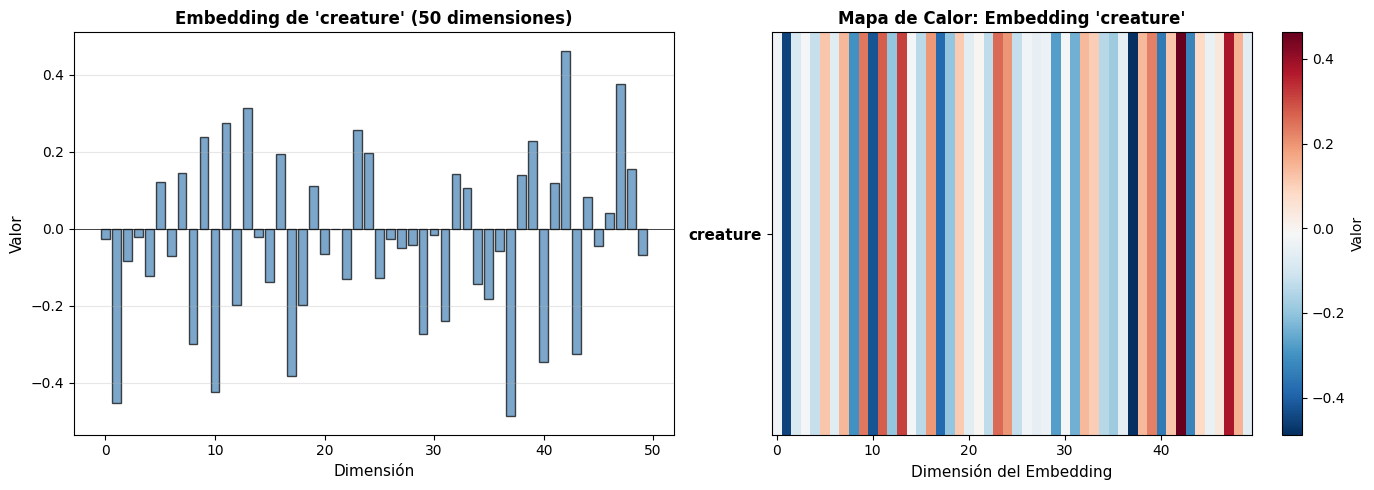


Embedding de 'creature':
  Vector de 50 dimensiones (primeros 10 valores):
  [-0.02695187 -0.45177928 -0.08317294 -0.02246795 -0.12279709  0.12051208
 -0.07009351  0.14434531 -0.29874557  0.23926629]

  Estadísticas:
    - Media: -0.0275
    - Desv. Est.: 0.2163
    - Mínimo: -0.4879
    - Máximo: 0.4630
    - Norma L2: 1.5421


In [14]:
print("\n[5.2] Analizando un embedding individual...\n")

# Obtener embedding de 'creature'
if 'creature' in w2v_model.wv:
    embedding = w2v_model.wv['creature']
    palabra_ejemplo = 'creature'
else:
    embedding = w2v_model.wv[vocabulario_w2v[0]]
    palabra_ejemplo = vocabulario_w2v[0]

# Visualizar
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Barras
ax1.bar(range(len(embedding)), embedding, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axhline(y=0, color='k', linestyle='-', linewidth=0.5)
ax1.set_xlabel('Dimensión', fontsize=11)
ax1.set_ylabel('Valor', fontsize=11)
ax1.set_title(f"Embedding de '{palabra_ejemplo}' (50 dimensiones)",
             fontsize=12, weight='bold')
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Heatmap vertical
embedding_reshaped = embedding.reshape(-1, 1)
im = ax2.imshow(embedding_reshaped.T, cmap='RdBu_r', aspect='auto')
ax2.set_yticks([0])
ax2.set_yticklabels([palabra_ejemplo], fontsize=11, weight='bold')
ax2.set_xlabel('Dimensión del Embedding', fontsize=11)
ax2.set_title(f"Mapa de Calor: Embedding '{palabra_ejemplo}'",
             fontsize=12, weight='bold')
plt.colorbar(im, ax=ax2, label='Valor')

plt.tight_layout()
plt.savefig('frankenstein_embedding_individual.png', dpi=300, bbox_inches='tight')
print("✓ Gráfico guardado: frankenstein_embedding_individual.png")
plt.show()

print(f"\nEmbedding de '{palabra_ejemplo}':")
print(f"  Vector de 50 dimensiones (primeros 10 valores):")
print(f"  {embedding[:10]}")
print(f"\n  Estadísticas:")
print(f"    - Media: {embedding.mean():.4f}")
print(f"    - Desv. Est.: {embedding.std():.4f}")
print(f"    - Mínimo: {embedding.min():.4f}")
print(f"    - Máximo: {embedding.max():.4f}")
print(f"    - Norma L2: {np.linalg.norm(embedding):.4f}")

# ETAPA 6: RESUMEN Y CONCLUSIONES

In [15]:
print("\n" + "="*80)
print("RESUMEN: PROCESAMIENTO COMPLETO DE FRANKENSTEIN")
print("="*80)

resumen = f"""
📊 CHECKPOINT 4: SEMÁNTICA DISTRIBUCIONAL

1️⃣  DATOS DE ENTRADA:
   • Archivo: libro.txt (Frankenstein)
   • Tamaño: {len(texto_frankenstein):,} caracteres
   • Tokens totales: {len(doc):,}
   • Oraciones procesadas: {len(corpus_lematizado):,}

2️⃣  PROCESAMIENTO:
   ✓ Tokenización con spaCy
   ✓ Eliminación de stop words y puntuación
   ✓ Lematización (reducción a formas base)
   ✓ Creación de corpus normalizado

3️⃣  VECTORIZACIÓN CLÁSICA:
   A. Bag-of-Words (BoW):
      - Matriz: {X_bow.shape[0]} oraciones × {X_bow.shape[1]} palabras
      - Tipo: Conteos (¿cuántas veces aparece cada palabra?)
      - Densidad: {X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]) * 100:.1f}%
      - Top palabra: "{vocab_bow[np.argsort(bow_sums)[-1]]}"

   B. TF-IDF:
      - Matriz: {X_tfidf.shape[0]} oraciones × {X_tfidf.shape[1]} palabras
      - Tipo: Ponderación por importancia relativa
      - Densidad: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.1f}%
      - Top palabra: "{vocab_tfidf[np.argsort(tfidf_sums)[-1]]}"

4️⃣  EMBEDDINGS (Word2Vec - Skip-gram):
   • Arquitectura: Red neuronal artificial (2 capas)
   • Vocabulario: {len(w2v_model.wv)} palabras
   • Dimensión: {w2v_model.vector_size} (dense, valores reales)
   • Contexto: Ventana de {5} palabras (Skip-gram)
   • Entrenamiento: {10} épocas
   • Similaridad: Coseno entre vectores densos

5️⃣  VISUALIZACIONES GENERADAS:
   ✓ frankenstein_word2vec_3d.png
     → Espacio semántico 3D con PCA
     → Proximidad = similitud semántica

   ✓ frankenstein_embeddings_heatmap.png
     → Palabras clave × Dimensiones del embedding
     → Colores = valores del embedding

   ✓ frankenstein_similitud_semantica.png
     → Matriz de similitud coseno
     → Verde oscuro = máxima similitud
     → Verde claro = baja similitud

   ✓ frankenstein_embedding_individual.png
     → Vector individual de 50 dimensiones
     → Distribución de valores

6️⃣  INSIGHTS CLAVE:
   • BoW destaca: Palabras frecuentes (conectores)
   • TF-IDF destaca: Palabras distintivas (conceptos)
   • Word2Vec captura: Contexto y semántica
   • Embeddings densos < Sparse BoW (50 vs 100 dims)
   • Contexto permite: Aritmética semántica

7️⃣  FLUJO COMPLETO (Checkpoint 2 → 4):
   Texto Crudo
      ↓
   Tokenización + Limpieza
      ↓
   BoW + TF-IDF (Vectorización clásica)
      ↓
   Word2Vec (Semántica distribucional)
      ↓
   Visualización 3D + Análisis

8️⃣  ARCHIVOS GENERADOS:
   • frankenstein_word2vec_3d.png
   • frankenstein_embeddings_heatmap.png
   • frankenstein_similitud_semantica.png
   • frankenstein_embedding_individual.png
   • vectorizacion_comparacion.csv
   • Este notebook (.ipynb)
"""

print(resumen)
print("="*80)
print("✅ ¡PROCESAMIENTO COMPLETADO EXITOSAMENTE!")
print("="*80)


RESUMEN: PROCESAMIENTO COMPLETO DE FRANKENSTEIN

📊 CHECKPOINT 4: SEMÁNTICA DISTRIBUCIONAL

1️⃣  DATOS DE ENTRADA:
   • Archivo: libro.txt (Frankenstein)
   • Tamaño: 438,842 caracteres
   • Tokens totales: 96,083
   • Oraciones procesadas: 3,249

2️⃣  PROCESAMIENTO:
   ✓ Tokenización con spaCy
   ✓ Eliminación de stop words y puntuación
   ✓ Lematización (reducción a formas base)
   ✓ Creación de corpus normalizado

3️⃣  VECTORIZACIÓN CLÁSICA:
   A. Bag-of-Words (BoW):
      - Matriz: 3249 oraciones × 100 palabras
      - Tipo: Conteos (¿cuántas veces aparece cada palabra?)
      - Densidad: 2.1%
      - Top palabra: "man"

   B. TF-IDF:
      - Matriz: 3249 oraciones × 100 palabras
      - Tipo: Ponderación por importancia relativa
      - Densidad: 2.1%
      - Top palabra: "man"

4️⃣  EMBEDDINGS (Word2Vec - Skip-gram):
   • Arquitectura: Red neuronal artificial (2 capas)
   • Vocabulario: 3188 palabras
   • Dimensión: 50 (dense, valores reales)
   • Contexto: Ventana de 5 palabras 

## 6.1 Exportar Modelos y Resultados

In [16]:
print("\n[6.1] Guardando modelos entrenados...\n")

# Guardar modelo Word2Vec
w2v_model.save('word2vec_frankenstein.model')
print("✓ Modelo Word2Vec guardado: word2vec_frankenstein.model")

# Guardar corpus
with open('corpus_final_lematizado.txt', 'w', encoding='utf-8') as f:
    for i, oracion in enumerate(corpus_lematizado, 1):
        f.write(f"[{i:05d}] {oracion}\n")
print("✓ Corpus lematizado guardado: corpus_final_lematizado.txt")

# Guardar vocabulario Word2Vec
vocab_w2v_df = pd.DataFrame({
    'palabra': list(w2v_model.wv.index_to_key),
    'frecuencia': [w2v_model.wv.get_vector(w).sum() for w in w2v_model.wv.index_to_key[:100]]
}).head(100)
vocab_w2v_df.to_csv('vocabulario_word2vec.csv', index=False)
print("✓ Vocabulario Word2Vec guardado: vocabulario_word2vec.csv")

print("\n✅ Todos los archivos exportados correctamente")


[6.1] Guardando modelos entrenados...

✓ Modelo Word2Vec guardado: word2vec_frankenstein.model
✓ Corpus lematizado guardado: corpus_final_lematizado.txt


ValueError: All arrays must be of the same length